# Color-Based First Redox Interface (FRI) Determination

This notebook implements the quantitative color-to-redox algorithm based on Kim et al. (2025).

## Conceptual Flowchart
![Algorithm Flowchart](Algorithm_Diagram.svg)

In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
from IPython.display import display, SVG

# Paths to Master Files
litho_master_path = '../../Python_Redox_Geochemistry/Lithology/Master_Lithology.csv'
color_map_path = '../../Python_Redox_Geochemistry/Lithology/Color_mapping.csv'
litho_map_path = '../../Python_Redox_Geochemistry/Lithology/Lithology_mapping.csv'

# Load datasets
df_litho = pd.read_csv(litho_master_path, encoding='iso-8859-1', sep=',')
df_cmap = pd.read_csv(color_map_path, encoding='iso-8859-1', sep=',')
df_lmap = pd.read_csv(litho_map_path, encoding='iso-8859-1', sep=',')

display(df_cmap.head(3))
display(df_lmap.head(3))

,Danish Color,English Equivalent,Raw Oxic Fraction,Depth Dependent?,Pox Definition / Logic,Munsell Code(s)
0,lys grågul,Pale yellow,0.67,No,P_ox=1,"2.5Y 7/3, 2.5Y 7/4"
1,sortbrun,Blackish brown,0,No,P_ox=0,"2.5Y 3/1, 7.5YR 2.5/2"
2,brun,Brown,0.26,Yes,0.25 down to 50m; then 0,"10YR 2/2, 10YR 5/3, 10YR 6/3, 2.5Y 5/2, 7.5YR ..."


,Lithology,Lithology_DA,Lithology_simple_DA,Lithology_EN,Lithology_simple_EN,Feature_factor,Factor
0,ml,moræneler,LER,moraine clay,CLAY,fine-grained,0.2
1,ms,morænesand,SAND,moraine sand,SAND,coarse-grained,1
2,mi,morænesilt,SILT,moraine silt,SILT,fine-grained,0.2


In [2]:
# --- CONFIGURATION FOR MOVABLE PARTS ---
CONFIG = {
    'BIN_SIZE_M': 0.2,        # Discretization interval (default 1.0m per Kim et al. 2025, but for shallow boreholes with high hetereogeneity like LOOP & DEMO--> 0.2)
    'REDOX_THRESHOLD': 0.1,      # P_ox threshold for boundary (default 0.1 per Kim et al. 2025)
    'PERSISTENCE_BINS': 5,      # Number of consecutive bins required below threshold (e.g., 1 for no persistence, 2 for 1m persistence if BIN_SIZE_M=1.0)
    'DIRECTION': 'bottom-up',     # 'top-down' (first reduced) or 'bottom-up' (deepest oxic)
    #the following param is not needed since its turn off/on is on the above cell
    #'APPLY_LITHOLOGY_FACTOR': False #Set to False to completely ignore the 0.2 fine-grained penalty and other litho factors,
    'DEPTH_DEPENDENT_MODEL': 'linear' # 'linear' (correct per paper) or 'exponential' (slightly subjective implementation)
}

## Logic for Depth-Dependent and Lithology Adjusted P_ox

We reconstruct the depth-dependent probabilities using piecewise linear interpolation referencing Table 4 from Kim et al. (2025).

### Rationale for Exponential Interpolation
The Kim et al. (2025) paper explicitly states in Section 3.4 that an **exponential function** was fitted to depth-dependent colors. The previous piecewise linear approach was a simplified approximation that correctly identified the $0.1$ threshold crossing (using $z_{0.1}$) but misrepresented the probability curve at shallower depths. 

By reverse-engineering the exponential decay coefficient ($k$) using the surface `Raw Oxic Fraction` ($A$) and the Table 4 anchor point ($z_{0.1}$), we calculate the exact curve: $P_{ox}(z) = A \cdot e^{-kz}$. 

This upgrade ensures that:
1. The $0.1$ threshold still triggers at exactly the $z_{0.1}$ depth from Table 4 (mathematically identical to before).
2. The curve correctly reflects the exponential decay described by the authors, allowing for sound scientific testing of **other threshold criteria** (e.g., $0.16$ or $0.2$).

In [3]:
import math
import re

# Table 4 params defined as (z_01, z_0)
table4_params = {
    'Grayish brown': (50.8, 76.6),
    'Gray': (40.1, 55.6),
    'Light brownish gray': (41.8, 59.9),
    'Pale brown': (39.2, 46.2), # Mapped from Light grayish brown
    'Light yellowish brown': (46.3, 51.6),
    'Dark grayish brown': (34.1, 55.9)
}

def calculate_base_pox(z, color_en, raw_pox, logic):
    logic = str(logic).strip()
    if logic == 'P_ox=1':
        return 1.0
    if logic == 'P_ox=0':
        return 0.0
    if logic == 'P_ox=0.35':
        return 0.35
    
    # X down to Y; then 0
    match = re.search(r'([0-9.]+) down to ([0-9]+)m', logic)
    if match:
        x_val = float(match.group(1))
        y_depth = float(match.group(2))
        return x_val if z <= y_depth else 0.0
        
    # Table 4 logic or Depth dependent for coarse
    if 'Table 4' in logic or 'Depth dependent' in logic:
        # Map exact string to Table 4 key
        key = str(color_en).strip()
        if key == 'Dark grayish brown' and raw_pox < 0.1: key = 'Dark grayish brown'
        elif key == 'Dark grayish brown': key = 'Grayish brown' # Gråbrun mapped to dark grayish brown but raw is 0.11
        
        if key not in table4_params:
            if 'Gray' in key: key = 'Gray'
            elif 'brownish gray' in key: key = 'Light brownish gray'
            elif 'grayish brown' in key: key = 'Grayish brown'
            else: return 0.0 # Fallback
            
        z_01, z_0 = table4_params.get(key, (0, 0))
        if z_01 == 0: return 0.0
        if z >= z_0: return 0.0
        
        A = float(raw_pox) if pd.notna(raw_pox) else 0.0
        
        if CONFIG.get('DEPTH_DEPENDENT_MODEL', 'linear') == 'linear':
            # Pure linear interpolation based strictly on Table 4 parameters: (z_01, 0.1) and (z_0, 0.0)
            slope = -0.1 / (z_0 - z_01)
            p = 0.1 + slope * (z - z_01)
            return max(0.0, min(1.0, p))
        else:
            # Original exponential implementation using Raw Oxic Fraction
            if A > 0.1:
                # Reconstruct the exponential decay k coefficient
                k = -math.log(0.1 / A) / z_01
                p = A * math.exp(-k * z)
                
                # Since exponential approaches 0 asymptotically, apply a linear taper 
                # from z_01 down to z_0 to strictly respect the paper's z_0 limit
                if z > z_01:
                    slope = -0.1 / (z_0 - z_01)
                    p = 0.1 + slope * (z - z_01)
            else:
                # If Raw Oxic Fraction is already <= 0.1 at surface (e.g. Dark grayish brown)
                # Do not project the slope backwards for shallow depths, which incorrectly increases p
                if z > z_01:
                    slope = -A / (z_0 - z_01)
                    p = A + slope * (z - z_01)
                else:
                    p = A
                
            return max(0.0, min(1.0, p))
        
    return float(raw_pox) if pd.notna(raw_pox) and str(raw_pox).replace('.','').isdigit() else 0.0

def get_litho_factor(litho_en, factor_str, pox):
    # Topsoil is ignored regardless of the flag to maintain valid structure
    if pd.isna(factor_str) or 'Ignore' in str(factor_str):
        return None # Exclude
        
    # If the user turned OFF lithology factors, we return 1.0 (no penalty)
    if not CONFIG.get('APPLY_LITHOLOGY_FACTOR', True):
        return 1.0
        
    if 'unless P_ox=1' in str(factor_str):
        return 1.0 if pox == 1.0 else 0.0
    try:
        return float(factor_str)
    except:
        return 1.0

def compute_interval_pox(row, df_cmap, df_lmap):
    z = (row['Depth_From'] + row['Depth_To']) / 2.0
    color_da = str(row['Color_Description']).strip()
    litho_da = str(row['Lithology']).strip()
    
    cmap_row = df_cmap[df_cmap['Danish Color'].str.lower() == color_da.lower()]
    lmap_row = df_lmap[df_lmap['Lithology'].str.lower() == litho_da.lower()]
    
    if cmap_row.empty or lmap_row.empty:
        return np.nan
        
    color_en = cmap_row.iloc[0]['English Equivalent']
    raw_pox = cmap_row.iloc[0]['Raw Oxic Fraction']
    try:
        raw_pox = float(raw_pox)
    except:
        raw_pox = 0.0
    logic = cmap_row.iloc[0]['Pox Definition / Logic']
    
    litho_factor_str = lmap_row.iloc[0]['Factor']
    litho_en = lmap_row.iloc[0]['Lithology_EN']
    
    base_pox = calculate_base_pox(z, color_en, raw_pox, logic)
    
    # If depth dependent for coarse but not coarse
    if 'Depth dependent for coarse' in str(logic) and 'coarse' not in str(lmap_row.iloc[0]['Feature_factor']):
        if CONFIG.get('APPLY_LITHOLOGY_FACTOR', True):
            base_pox = 0.0
        
    factor = get_litho_factor(litho_en, litho_factor_str, base_pox)
    if factor is None: 
        return np.nan
        
    return base_pox * factor



In [4]:
def calculate_fri_for_borehole(loop, id_val, df_litho, df_cmap, df_lmap):
    # Filter data
    sub = df_litho[(df_litho["LOOPNr"] == loop) & (df_litho["ID"] == id_val)].copy()
    if sub.empty: return None
    
    sub["P_ox"] = sub.apply(lambda r: compute_interval_pox(r, df_cmap, df_lmap), axis=1)
    sub = sub.dropna(subset=["P_ox"])
    
    if sub.empty: return None
    
    # Create bins
    max_depth = int(np.ceil(sub["Depth_To"].max()))
    if max_depth <= 0: return None
    bins = np.round(np.arange(0, max_depth + 1, CONFIG["BIN_SIZE_M"]), 3)
    if len(bins) < 2: return None
    bin_centers = bins[:-1] + CONFIG["BIN_SIZE_M"] / 2.0
    binned_pox = np.zeros(len(bins) - 1)
    
    for i in range(len(bins)-1):
        b_start, b_end = bins[i], bins[i+1]
        weighted_sum = 0
        total_length = 0
        
        for _, row in sub.iterrows():
            overlap_start = max(b_start, row["Depth_From"])
            overlap_end = min(b_end, row["Depth_To"])
            if overlap_start < overlap_end:
                length = overlap_end - overlap_start
                weighted_sum += length * row["P_ox"]
                total_length += length
        
        if total_length > 0:
            binned_pox[i] = weighted_sum / total_length
        else:
            binned_pox[i] = np.nan
            
    # Find FRI based on CONFIG
    fri_depth = None
    if CONFIG["DIRECTION"] == "top-down":
        for i in range(len(binned_pox) - CONFIG["PERSISTENCE_BINS"] + 1):
            valid_slice = binned_pox[i:i+CONFIG["PERSISTENCE_BINS"]]
            if not np.isnan(valid_slice).any() and np.all(valid_slice <= CONFIG["REDOX_THRESHOLD"]):
                # Place interface EXACTLY at the top edge of the first reduced block
                fri_depth = bins[i]
                break
    elif CONFIG["DIRECTION"] == "bottom-up":
        # Search from bottom up, looking for a valid PERSISTENCE block of OXIC sediment
        deepest_oxic_idx = -1
        req_bins = CONFIG["PERSISTENCE_BINS"]
        
        for i in range(len(binned_pox) - req_bins, -1, -1):
            valid_slice = binned_pox[i:i+req_bins]
            if not np.isnan(valid_slice).any() and np.all(valid_slice > CONFIG["REDOX_THRESHOLD"]):
                # Found a continuous block of oxic sediment!
                deepest_oxic_idx = i + req_bins - 1
                break
                
        if deepest_oxic_idx != -1:
            # We found the deepest oxic block. Now verify there is a reduced layer below it!
            has_reduced_below = False
            for j in range(deepest_oxic_idx + 1, len(binned_pox)):
                if not np.isnan(binned_pox[j]):
                    if binned_pox[j] <= CONFIG["REDOX_THRESHOLD"]:
                        has_reduced_below = True
                    break # Only check the very next valid bin
                    
            if has_reduced_below:
                # Place interface EXACTLY at the bottom edge of the oxic block
                fri_depth = bins[deepest_oxic_idx + 1]
            else:
                # Log ends in oxic material (no reduced data below). Interface is deeper than borehole.
                fri_depth = None
        else:
            # If we never found a persistent oxic layer (the whole log is effectively reduced), 
            # the interface is at the very top (the top edge of the first valid bin)
            for i in range(len(binned_pox)):
                if not np.isnan(binned_pox[i]):
                    fri_depth = bins[i]
                    break

    return {"LOOPNr": loop, "ID": id_val, "Color_FRI_Depth": fri_depth, "Binned_Pox": binned_pox, "Bin_Centers": bin_centers}




## Borehole Level Analysis

We process intervals, compute 1m binned values using length-weighting, and find the First Redox Interface (FRI).

## Methodological Comparison: Color FRI vs. Probe FRI (Auto_1)

We compare the Color-Based FRI with the computationally derived primary redox interface (Auto_1) from the redox probe data. We also validate both against nitrate reduction criteria.

In [5]:
import re
import seaborn as sns
from scipy.stats import pearsonr

# --- ID Normalization ---
def normalize_id(row, source):
    loop = str(row['LOOPNr']).strip().upper()
    raw_id = str(row['ID']).strip()

    if source == 'Redox':
        norm = re.sub(r'[a-z]$', '', raw_id, flags=re.IGNORECASE)
        if loop == 'DEMO' and norm.isdigit(): norm = f"D{norm}"
        if loop == 'LOOP4':
            norm = norm.replace('Geological Window-', 'GeoW-')
            norm = norm.replace('interglacial sand-', 'IS-')
            norm = norm.replace('meltwater sand-', 'MS-')
            norm = norm.replace('Til layer-', 'TL-')
        return norm
    elif source == 'Geochem':
        if loop in ['LOOP2', 'LOOP3', 'LOOP6']:
            return re.sub(r'^[P]', '', raw_id)
        return raw_id
    return raw_id

# Load Probe Interfaces
df_algo = pd.read_csv('../Extracted_Advanced_Interfaces.csv')
df_algo['Norm_ID'] = df_algo.apply(lambda row: normalize_id(row, 'Redox'), axis=1)

# Average multiple logs per borehole
df_interfaces = df_algo.groupby(['LOOPNr', 'Norm_ID'])[['Main_Drop_Z']].mean().reset_index()
df_interfaces = df_interfaces.rename(columns={'Main_Drop_Z': 'Auto_1'})

# Load Color Results (already in memory as df_results)
df_color = df_results.copy()
df_color['Norm_ID'] = df_color.apply(lambda row: normalize_id(row, 'Geochem'), axis=1)

# Merge
df_comp = pd.merge(df_interfaces, df_color[['LOOPNr', 'Norm_ID', 'Color_FRI_Depth']], on=['LOOPNr', 'Norm_ID'], how='inner')
df_comp = df_comp.dropna(subset=['Auto_1', 'Color_FRI_Depth'])

display(df_comp.head())
print(f"Coincident Color and Probe interfaces: {len(df_comp)}")

,LOOPNr,Norm_ID,Auto_1,Color_FRI_Depth
0,DEMO,D6,7.572000,0.9
1,DEMO,D7,8.146250,1.1
2,LOOP2,1,10.570000,1.1
3,LOOP2,2,4.352333,1.5
4,LOOP2,2A,1.875500,3.5


Coincident Color and Probe interfaces: 23


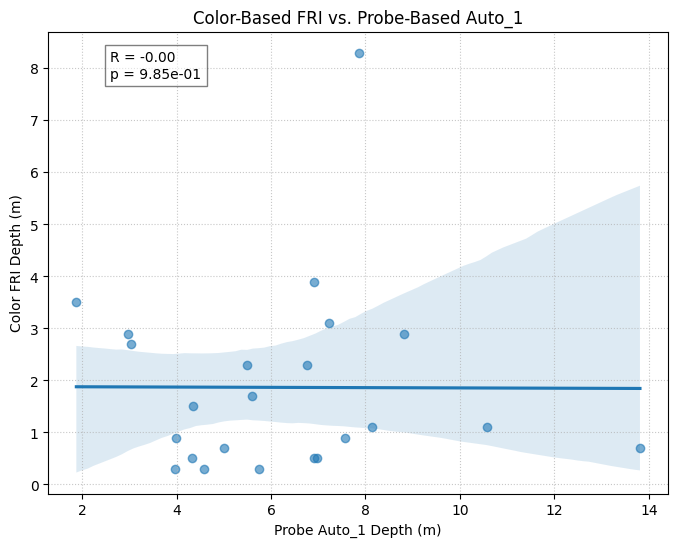

Mean Error: -4.33 m
MAE: 4.51 m


In [6]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df_comp, x='Auto_1', y='Color_FRI_Depth', scatter_kws={'alpha':0.6})

r, p = pearsonr(df_comp['Auto_1'], df_comp['Color_FRI_Depth'])
plt.text(0.1, 0.9, f'R = {r:.2f}\np = {p:.2e}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))

plt.title('Color-Based FRI vs. Probe-Based Auto_1')
plt.xlabel('Probe Auto_1 Depth (m)')
plt.ylabel('Color FRI Depth (m)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

df_comp['Error'] = df_comp['Color_FRI_Depth'] - df_comp['Auto_1']
print(f"Mean Error: {df_comp['Error'].mean():.2f} m")
print(f"MAE: {df_comp['Error'].abs().mean():.2f} m")

## Geochemical Validation: Nitrate Reduction

We evaluate how well both interface methods align with the observed nitrate reduction profiles.

In [7]:
geochem_path = '../../Python_Redox_Geochemistry/Geochemistry/Master_Geochemistry.csv'
df_geochem = pd.read_csv(geochem_path)
df_geochem['Norm_ID'] = df_geochem.apply(lambda row: normalize_id(row, 'Geochem'), axis=1)

# Extract Nitrate
if 'NO₃⁻ [mg/L]' in df_geochem.columns and 'GW_NO₃⁻ [mg/L]' in df_geochem.columns:
    df_geochem['Nitrate'] = df_geochem['NO₃⁻ [mg/L]'].fillna(df_geochem['GW_NO₃⁻ [mg/L]'])
else:
    df_geochem['Nitrate'] = df_geochem['NO₃⁻ [mg/L]']

df_geochem = df_geochem.dropna(subset=['Depth (m)', 'Nitrate'])

def validate_interface(interface_z, depths, nitrates):
    if pd.isna(interface_z): return None
    NO_NITRATE_THRESHOLD = 1.0
    
    above_idx = depths < interface_z
    baseline_n = np.max(nitrates[above_idx]) if np.any(above_idx) else np.max(nitrates)
    
    # Reduction 1m
    mask1 = (depths >= interface_z - 1.0) & (depths <= interface_z + 1.0)
    red1 = False
    if np.any(mask1):
        mmin = np.min(nitrates[mask1])
        if mmin < NO_NITRATE_THRESHOLD or mmin <= 0.5 * baseline_n: red1 = True
        
    # No nitrate 2m below
    mask2 = (depths > interface_z) & (depths <= interface_z + 2.0)
    nn2 = False
    if np.any(mask2):
        if np.any(nitrates[mask2] < NO_NITRATE_THRESHOLD): nn2 = True
        
    return {'Red_1m': red1, 'NoN_2m': nn2}

val_results = []
for _, row in df_comp.iterrows():
    loop, norm_id = row['LOOPNr'], row['Norm_ID']
    g = df_geochem[(df_geochem['LOOPNr'] == loop) & (df_geochem['Norm_ID'] == norm_id)]
    if g.empty: continue
    
    depths = g['Depth (m)'].values
    nitrates = g['Nitrate'].values
    
    res_auto = validate_interface(row['Auto_1'], depths, nitrates)
    res_color = validate_interface(row['Color_FRI_Depth'], depths, nitrates)
    
    val_results.append({
        'Borehole': f"{loop} {norm_id}",
        'Auto_Red1': res_auto['Red_1m'],
        'Auto_NoN2': res_auto['NoN_2m'],
        'Color_Red1': res_color['Red_1m'],
        'Color_NoN2': res_color['NoN_2m']
    })

df_val = pd.DataFrame(val_results)
display(df_val.head())

stats = pd.DataFrame({
    'Method': ['Probe (Auto_1)', 'Color FRI'],
    'Nitrate Reduction (1m)': [
        f"{df_val['Auto_Red1'].mean()*100:.0f}%",
        f"{df_val['Color_Red1'].mean()*100:.0f}%"
    ],
    'No Nitrate Below (2m)': [
        f"{df_val['Auto_NoN2'].mean()*100:.0f}%",
        f"{df_val['Color_NoN2'].mean()*100:.0f}%"
    ]
})
display(stats)

,Borehole,Auto_Red1,Auto_NoN2,Color_Red1,Color_NoN2
0,DEMO D6,True,True,False,True
1,DEMO D7,True,False,False,False
2,LOOP2 1,False,False,False,False
3,LOOP2 2,True,True,False,False
4,LOOP2 2A,True,True,True,True


,Method,Nitrate Reduction (1m),No Nitrate Below (2m)
0,Probe (Auto_1),83%,65%
1,Color FRI,26%,30%
